# EX6 ANN MNIST

In [1]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as opt
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms import transforms

## data preparation

In [2]:
train_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=True,transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=False,transform=transforms.ToTensor())


let's visualize

Text(0.5, 1.0, '5')

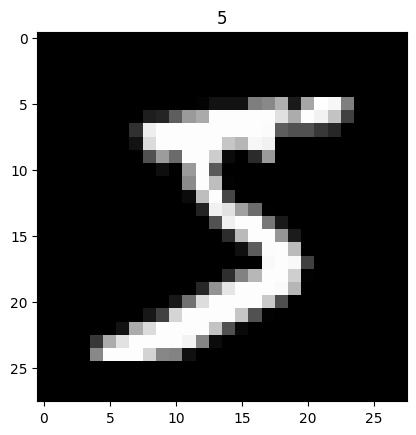

In [3]:
plt.imshow(train_dataset.data[0],cmap='gray')
plt.title(str(train_dataset.targets[0].item()))


data processing continued

In [4]:
print(f'train x shape {train_dataset.data.shape} y_train {train_dataset.targets.shape}\ntest x shape {test_dataset.data.shape} y_test {test_dataset.targets.shape}')

train x shape torch.Size([60000, 28, 28]) y_train torch.Size([60000])
test x shape torch.Size([10000, 28, 28]) y_test torch.Size([10000])


In [5]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=128,shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,batch_size=128,shuffle=False)

## build the model

In [6]:
model = nn.Sequential(
    nn.Linear(28*28,128),
    nn.ReLU(),
    nn.Linear(128,10)
    # nn.Softmax() - not needed 
)

## set device to GPU(if exists)

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device=device)

cuda:0


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = opt.Adam(model.parameters(),lr=0.0001)

## Training the model

In [9]:
EPOCHS = 10
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(EPOCHS): 
    n_correct = 0
    n_total = 0
    train_loss = []
    # 0. batch loop 
    for inputs,targets in train_loader:
        #1. zero gradients  that optimizer are in charge
        optimizer.zero_grad()
        
        # put inputs and targets into device(GPU)
        inputs,targets = inputs.to(device),targets.to(device)

        # flatten the input (because it's ANN NxD)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)

        loss = criterion(outputs,targets)
        loss.backward()
        optimizer.step()
        _,indxs = torch.max(outputs,1)
        
        #calculate accuracy
       
        n_total += indxs.shape[0]
        n_correct += (indxs == targets).sum().item()
        #batch loss
        train_loss.append(loss.item())

    train_losses.append(np.mean(train_loss))
    train_accuracy.append(n_correct/n_total)
    test_loss = []
    #test
    n_correct = 0
    n_total = 0
    for inputs,targets in test_loader:
        inputs,targets = inputs.to(device),targets.to(device)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)
        loss = criterion(outputs,targets)
        test_loss.append(loss.item())
        _,indxs = torch.max(outputs,1)

    #calculate accuracy
 
    n_total += indxs.shape[0]
    n_correct += (indxs == targets).sum().item()
    test_losses.append(np.mean(test_loss))
    test_accuracy.append(n_correct/n_total)


    print(f'train_loss {train_losses[-1]} test_loss {test_losses[-1]} train acc: {train_accuracy[-1]} test acc: {test_accuracy[-1]}')
    #acc = n_correct /n_total

train_loss 1.1979911242212569 test_loss 0.5715389478055737 train acc: 0.7604 test acc: 0.8125
train_loss 0.4678316014026528 test_loss 0.37505878715575497 train acc: 0.8858166666666667 test acc: 0.9375
train_loss 0.35813921473936233 test_loss 0.3175489147064052 train acc: 0.9046333333333333 test acc: 0.9375
train_loss 0.31363332303348124 test_loss 0.2871690928888849 train acc: 0.9131166666666667 test acc: 0.9375
train_loss 0.2866664050357428 test_loss 0.26723408569357815 train acc: 0.9201333333333334 test acc: 0.9375
train_loss 0.26700216727152565 test_loss 0.25185800831812094 train acc: 0.9255666666666666 test acc: 0.9375
train_loss 0.25144903396746754 test_loss 0.23834463699331768 train acc: 0.9300666666666667 test acc: 0.9375
train_loss 0.23786052202047314 test_loss 0.22809602341414253 train acc: 0.93335 test acc: 0.9375
train_loss 0.2261499499779012 test_loss 0.21790210941594235 train acc: 0.9368333333333333 test acc: 0.9375
train_loss 0.21492148343243325 test_loss 0.207781987052552

In [10]:
#predict:

# _,predictions = torch.max(outputs,1)

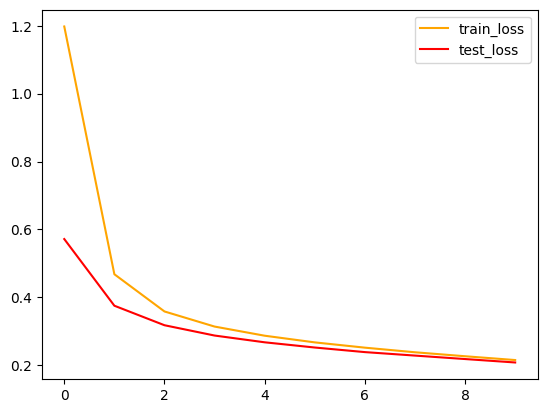

In [11]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_losses,label='train_loss',color='orange')
plt.plot(x,test_losses,label='test_loss',color='red')
plt.legend()

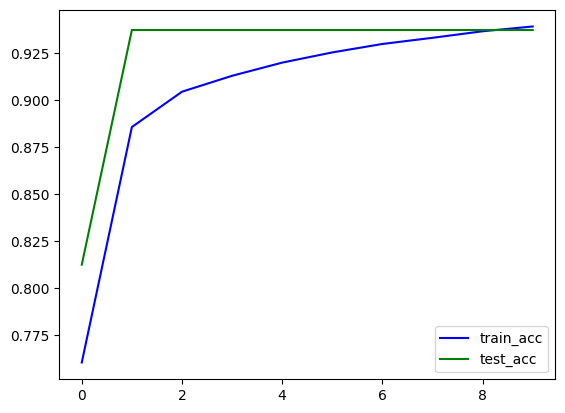

In [12]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_accuracy,label='train_acc',color='blue')
plt.plot(x,test_accuracy,label='test_acc',color='green')
plt.legend()

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [22]:
y= []
y_hat = []
for inputs,outputs in test_loader:
    inputs,outputs = inputs.to(device),outputs.to(device)
    inputs= inputs.view(-1,28*28)
    predict = model(inputs)
    _,predict = torch.max(predict,1)
    y = np.concatenate((y,outputs.cpu().numpy()))
    y_hat = np.concatenate((y_hat,predict.cpu().numpy()))


In [23]:
test_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [ ]:
cm = confusion_matrix(y_true=y,y_pred=y_hat)

array([[ 967,    0,    1,    1,    0,    3,    5,    2,    1,    0],
       [   0, 1117,    2,    2,    1,    1,    4,    2,    6,    0],
       [   8,    1,  959,   10,    9,    2,    9,    8,   22,    4],
       [   1,    1,   16,  936,    0,   19,    1,   13,   16,    7],
       [   1,    1,    6,    0,  924,    0,   12,    2,    6,   30],
       [   6,    3,    2,   28,    6,  796,   14,    6,   24,    7],
       [   9,    3,    6,    0,    8,   15,  914,    1,    2,    0],
       [   2,    7,   23,    5,    5,    1,    0,  964,    3,   18],
       [   5,    6,    6,   20,   10,   15,   10,   11,  883,    8],
       [  10,    7,    1,   13,   29,    6,    1,   15,    4,  923]],
      dtype=int64)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_true=y,y_pred=y_hat,display_labels=test_dataset.classes)